<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/GPU_Accelerated_S21_CPW_Resonator_Sim_Basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Cell A: environment set-up
# Ensure GPU-aware CuPy plus helpers are installed, and fix plot DPI up front
!pip install -q cupy-cuda12x tqdm pylint           # CUDA 12 backend for NVIDIA L4

import cupy as cp
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm

#  Set figure DPI globally before any plots are created
mpl.rcParams['figure.dpi'] = 250        # higher-resolution figures for reports & papers

# Safety check: verify GPU visibility
try:
    dev = cp.cuda.runtime.getDevice()
    print(f"CuPy sees CUDA device #{dev}: {cp.cuda.runtime.getDeviceProperties(dev)['name'].decode()}")
except cp.cuda.runtime.CUDARuntimeError as err:
    raise EnvironmentError(
        "CuPy cannot access a CUDA device. Make sure Colab 'Runtime ▶︎ Change runtime type' is set to GPU."
    ) from err

CuPy sees CUDA device #0: NVIDIA L4


In [2]:
# Cell B: define simulation grids and RNG seed
SEED = 42
cp.random.seed(SEED)

N_SAMPLES = 500_000
N_FREQ = 201
F_MIN_GHZ, F_MAX_GHZ = 4.8, 5.2

# Frequency vector on GPU, units = GHz
freq = cp.linspace(F_MIN_GHZ, F_MAX_GHZ, N_FREQ)

# Helper for GHz↔Hz conversions when desired
GHz = 1e9

In [3]:
# Cell C: draw random quality factors & centre frequencies
def draw_parameters(n_samples: int) -> tuple[cp.ndarray, cp.ndarray, cp.ndarray]:
    """Return (f0, Qi, Qc) vectors on the GPU."""
    f0 = cp.random.normal(loc=5.0, scale=0.01, size=n_samples)  # GHz
    Qi = cp.random.lognormal(mean=cp.log(8e4), sigma=0.25, size=n_samples)
    Qc = cp.random.lognormal(mean=cp.log(2e4), sigma=0.20, size=n_samples)
    return f0, Qi, Qc

In [4]:
# Cell D: vectorised computation of S21 for all samples & freqs
def compute_s21(
    f_vec: cp.ndarray,
    f0_vec: cp.ndarray,
    Qi_vec: cp.ndarray,
    Qc_vec: cp.ndarray,
) -> cp.ndarray:
    """
    Return complex S21 array with shape (n_samples, n_freqs).
    Memory footprint: n_samples * n_freqs * 16 bytes.
    """
    # Broadcast arrays: (n_samples, 1) versus (1, n_freqs)
    f0 = f0_vec[:, None]
    Qi = Qi_vec[:, None]
    Qc = Qc_vec[:, None]

    Ql = 1.0 / (1.0 / Qi + 1.0 / Qc)
    # Δf/f0 term
    df_over_f0 = (f_vec[None, :] - f0) / f0
    # Complex response
    notch = (Ql / Qc) / (1.0 + 2.0j * Ql * df_over_f0)
    return 1.0 - notch

In [5]:
# Cell E: main execution block
%%time
f0_s, Qi_s, Qc_s = draw_parameters(N_SAMPLES)

# Compute in manageable chunks if VRAM is tight; otherwise one shot
CHUNK = 100_000
mag_sum = cp.zeros(N_FREQ)
mag2_sum = cp.zeros(N_FREQ)

for start in tqdm(range(0, N_SAMPLES, CHUNK)):
    end = min(start + CHUNK, N_SAMPLES)
    s21 = compute_s21(freq, f0_s[start:end], Qi_s[start:end], Qc_s[start:end])
    mag = cp.abs(s21)
    mag_sum += mag.sum(axis=0)
    mag2_sum += (mag ** 2).sum(axis=0)

# Mean & standard deviation of |S21|
mean_mag = mag_sum / N_SAMPLES
std_mag = cp.sqrt(mag2_sum / N_SAMPLES - mean_mag ** 2)

# Bring small arrays back to host for plotting
mean_mag_cpu = mean_mag.get()
std_mag_cpu = std_mag.get()
freq_cpu = freq.get()

100%|██████████| 5/5 [00:01<00:00,  3.51it/s]


CPU times: user 2.05 s, sys: 44.8 ms, total: 2.09 s
Wall time: 2.09 s


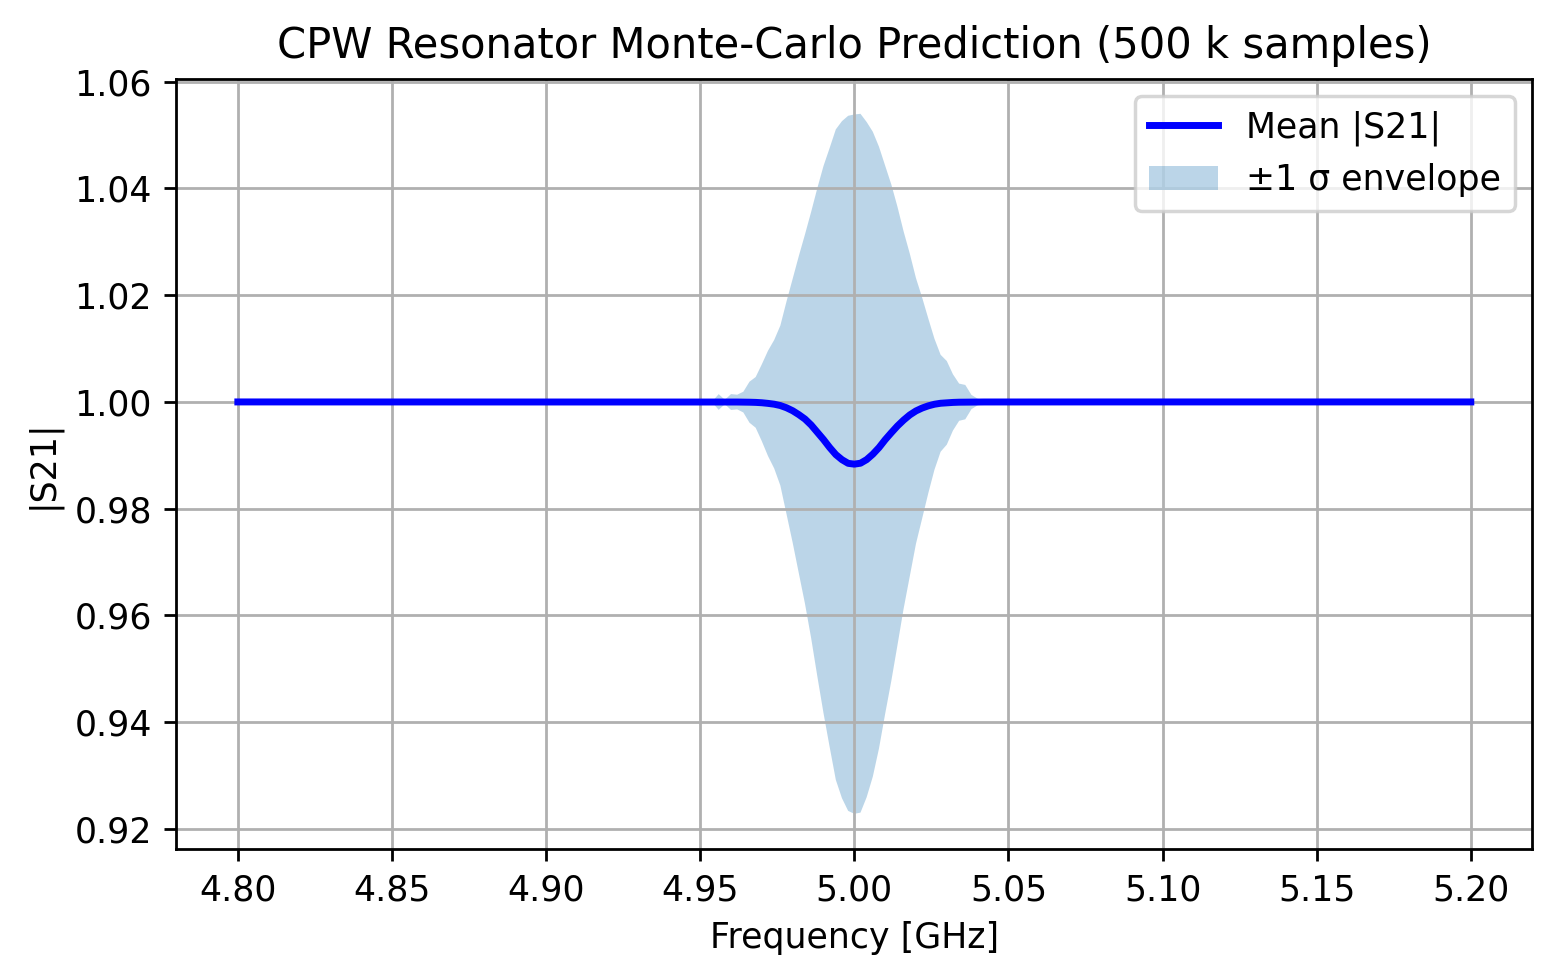

In [11]:
# Cell F: visualise transmission magnitude statistics (blue line)
plt.figure(figsize=(7, 4))
plt.plot(
    freq_cpu,
    mean_mag_cpu,
    lw=2,
    color='blue',           # ⬅️  explicit blue line
    label='Mean |S21|'
)
plt.fill_between(
    freq_cpu,
    mean_mag_cpu - std_mag_cpu,
    mean_mag_cpu + std_mag_cpu,
    alpha=0.3,
    label='±1 σ envelope'
)
plt.xlabel('Frequency [GHz]')
plt.ylabel('|S21|')
plt.title('CPW Resonator Monte-Carlo Prediction (500 k samples)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [7]:
# Cell G: export mean & std to CSV in case you want offline analysis
import pandas as pd

df = pd.DataFrame(
    {
        "freq_GHz": freq_cpu,
        "mean_mag": mean_mag_cpu,
        "std_mag": std_mag_cpu,
    }
)
df.to_csv("cpw_resonator_S21_stats.csv", index=False)
print("CSV written: cpw_resonator_S21_stats.csv")

CSV written: cpw_resonator_S21_stats.csv


In [8]:
# Cell H: write the simulation core to a module and run pylint for hygiene
%%writefile cpw_mc.py
"""GPU-accelerated CPW S21 Monte-Carlo simulation."""
import cupy as cp

GHz = 1e9


def draw_parameters(n_samples: int, seed: int = 42):
    """Draw f0, Qi, Qc samples."""
    cp.random.seed(seed)
    f0 = cp.random.normal(5.0, 0.01, n_samples)
    Qi = cp.random.lognormal(cp.log(8e4), 0.25, n_samples)
    Qc = cp.random.lognormal(cp.log(2e4), 0.20, n_samples)
    return f0, Qi, Qc


def compute_s21(f_vec, f0_vec, Qi_vec, Qc_vec):
    """Vectorised notch-type S21."""
    f0 = f0_vec[:, None]
    Qi = Qi_vec[:, None]
    Qc = Qc_vec[:, None]
    Ql = 1.0 / (1.0 / Qi + 1.0 / Qc)
    df_over_f0 = (f_vec[None, :] - f0) / f0
    notch = (Ql / Qc) / (1.0 + 2.0j * Ql * df_over_f0)
    return 1.0 - notch

Writing cpw_mc.py
